# Paper figures — Manning roughness sensitivity

Generates all paper figures in PDF + PNG at publication resolution.
Each section corresponds to a numbered figure in the article.

| Figure | Content |
|--------|---------|
| Fig. 1 | Manning distributions by land-use class |
| Fig. 2 | Monte Carlo ensemble boxplots |
| Fig. 3 | Intra-model sensitivity (Manning vs outputs scatter, **coloured by regime**) |
| Fig. 4 | Inter-model comparison: 1:1 scatter and KDE |
| Fig. 5 | Hydraulic bifurcation (maps + distributions + predictor) |
| Fig. 6 | Coefficient of variation by model and metric |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import rioxarray as rxr
import xarray as xr
from scipy import stats, ndimage
from scipy.stats import gaussian_kde
from sklearn.mixture import GaussianMixture

# ── Publication style ────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":         9,
    "axes.labelsize":    9,
    "axes.titlesize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "axes.linewidth":    0.7,
    "axes.grid":        True,
    "grid.alpha":       0.25,
    "grid.linewidth":   0.5,
    "lines.linewidth":  1.2,
})

FIG_DIR = Path("../../../../papers/besaya_manning_sensitivity/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figures → {FIG_DIR.resolve()}")


Figures → /Users/salvadornavasfernandez/Desktop/Github/HYDRA/papers/besaya_manning_sensitivity/figures


## Fig 0 — Location map


In [2]:
import os
if os.getenv('HYDRA_RUN_MAP_FIGURES', '0') == '1':
    
    # ── Fig 0: Location map (redesigned) ─────────────────────────────────────────
    # 3 panels:
    #   (a) Spain + Cantabria regional context (no Europe panel)
    #   (b) Satellite orthoimage of simulation domain (ESRI World Imagery via contextily)
    #   (c) Land use classification map with 9 classes + areas (ha)
    
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    import matplotlib.patheffects as pe
    from matplotlib.gridspec import GridSpec
    from matplotlib.colors import ListedColormap, BoundaryNorm
    import matplotlib.ticker as mticker
    import numpy as np
    import urllib.request, pathlib as _pl
    import rasterio
    from rasterio.warp import transform_bounds
    import contextily as cx
    
    # ── Natural Earth (Spain / Cantabria context) ─────────────────────────────────
    _ne_zip = _pl.Path('/tmp/ne_countries.zip')
    _ne_url = 'https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip'
    if not _ne_zip.exists():
        urllib.request.urlretrieve(_ne_url, _ne_zip)
    world = gpd.read_file(f'zip://{_ne_zip}')
    world = world.rename(columns={'SOVEREIGNT': 'name', 'CONTINENT': 'continent'})
    spain = world[world['name'] == 'Spain']
    
    SITE_LON, SITE_LAT = -4.052, 43.238   # Corrales de Buelna
    
    # ── Land cover raster ─────────────────────────────────────────────────────────
    LC_PATH = _pl.Path('/Volumes/My Passport 2/COPIA_IH/E/Rugosidades_UCLM/HEC_RAS/LandCover.tif')
    
    LC_CLASSES = {
        1:  ('Trees',             '#2d8653'),
        2:  ('Dense vegetation',  '#6abf69'),
        4:  ('Urban vegetation',  '#b8d96b'),
        5:  ('Infrastructure',    '#aaaaaa'),
        6:  ('Sparse vegetation', '#e6c86e'),
        7:  ('Residential',       '#d9534f'),
        8:  ('Industrial',        '#9467bd'),
        9:  ('River',             '#4292c6'),
        10: ('Brushland',         '#c9a035'),
    }
    LC_AREAS_HA = {1:25.2, 2:49.9, 4:123.4, 5:43.0, 6:473.0,
                   7:199.8, 8:120.1, 9:25.5, 10:25.7}
    
    with rasterio.open(LC_PATH) as src:
        lc_data  = src.read(1).astype(float)
        lc_data[lc_data == 0] = np.nan          # NoData → NaN
        lc_bounds_25830 = src.bounds            # EPSG:25830
        lc_transform   = src.transform
    
    # Domain bounds in EPSG:3857 (contextily) and EPSG:4326 (Iberian panel)
    b3857 = transform_bounds('EPSG:25830','EPSG:3857',
                              lc_bounds_25830.left, lc_bounds_25830.bottom,
                              lc_bounds_25830.right, lc_bounds_25830.top)
    b4326 = transform_bounds('EPSG:25830','EPSG:4326',
                              lc_bounds_25830.left, lc_bounds_25830.bottom,
                              lc_bounds_25830.right, lc_bounds_25830.top)
    
    # ── Download satellite tile (15 % margin) ─────────────────────────────────────
    mx = (b3857[2]-b3857[0]) * 0.15
    my = (b3857[3]-b3857[1]) * 0.15
    b3857_m = (b3857[0]-mx, b3857[1]-my, b3857[2]+mx, b3857[3]+my)
    sat_img, sat_ext = cx.bounds2img(*b3857_m, ll=False,
                                      source=cx.providers.Esri.WorldImagery, zoom=15)
    
    # ── Figure layout ─────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(7.2, 3.6))
    gs  = GridSpec(1, 3, figure=fig, width_ratios=[1.1, 1.3, 1.6], wspace=0.28)
    
    # ────────────────────────────────────────────────────────────────────────────
    # Panel (a) — Spain / Cantabria context
    # ────────────────────────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    world.plot(ax=ax1, color='#eeeeee', edgecolor='#aaaaaa', linewidth=0.25)
    spain.plot(ax=ax1, color='#cfe0f5', edgecolor='#555555', linewidth=0.5)
    
    # Cantabria bounding box (approximate)
    cant_lon = [-4.85, -3.05, -3.05, -4.85, -4.85]
    cant_lat = [42.98, 42.98, 43.51, 43.51, 42.98]
    ax1.fill(cant_lon, cant_lat, color='#4878d0', alpha=0.40, zorder=3)
    ax1.plot(cant_lon, cant_lat, color='#4878d0', lw=0.8, zorder=4)
    
    # Besaya river (schematic)
    ax1.plot([-4.05,-4.04,-4.02,-3.98,-3.93,-3.87],
             [43.24,43.26,43.29,43.34,43.38,43.39],
             color='#2166ac', lw=1.2, zorder=5)
    
    # Study site
    ax1.plot(SITE_LON, SITE_LAT, marker='*', ms=9, color='#c44e52',
             zorder=8, markeredgecolor='white', markeredgewidth=0.6)
    
    ax1.annotate('Cantabrian\nSea', xy=(-4.0, 43.50), fontsize=6,
                 color='#2166ac', ha='center', style='italic', zorder=6)
    ax1.annotate('Corrales\nde Buelna', xy=(SITE_LON, SITE_LAT),
                 xytext=(SITE_LON+0.55, SITE_LAT-0.22),
                 fontsize=5.5, color='#c44e52',
                 arrowprops=dict(arrowstyle='-', color='#c44e52', lw=0.6), ha='left')
    
    ax1.set_xlim(-9.5, 4.5); ax1.set_ylim(35.8, 44.2)
    ax1.set_title('(a) Study reach location', fontsize=7.5, pad=3)
    ax1.set_xlabel('Longitude (°)', fontsize=6, labelpad=1)
    ax1.set_ylabel('Latitude (°)', fontsize=6, labelpad=1)
    ax1.tick_params(labelsize=5.5)
    ax1.grid(True, linewidth=0.25, alpha=0.5)
    ax1.legend(handles=[
        mpatches.Patch(color='#cfe0f5', label='Spain'),
        mpatches.Patch(color='#4878d0', alpha=0.6, label='Cantabria'),
        plt.Line2D([],[],marker='*',color='#c44e52',ms=7,ls='none',
                   markeredgecolor='white',markeredgewidth=0.5,label='Study site'),
    ], fontsize=5.5, loc='lower right', handlelength=1, borderpad=0.4)
    
    # ────────────────────────────────────────────────────────────────────────────
    # Panel (b) — Satellite orthoimage of simulation domain
    # ────────────────────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1])
    ax2.imshow(sat_img, extent=sat_ext, origin='upper', interpolation='bilinear')
    
    # Domain boundary (LandCover extent) in EPSG:3857
    rect = plt.Rectangle((b3857[0], b3857[1]),
                          b3857[2]-b3857[0], b3857[3]-b3857[1],
                          linewidth=1.4, edgecolor='yellow', facecolor='none', zorder=5)
    ax2.add_patch(rect)
    
    # Format axes as km offsets from domain centre
    cx_mid = (b3857[0]+b3857[2])/2
    cy_mid = (b3857[1]+b3857[3])/2
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{(v-cx_mid)/1000:+.1f}'))
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{(v-cy_mid)/1000:+.1f}'))
    ax2.tick_params(labelsize=5.5)
    ax2.set_xlim(sat_ext[0], sat_ext[1])
    ax2.set_ylim(sat_ext[2], sat_ext[3])
    ax2.set_xlabel('Easting offset (km)', fontsize=6, labelpad=1)
    ax2.set_ylabel('Northing offset (km)', fontsize=6, labelpad=1)
    ax2.set_title('(b) Simulation domain (satellite)', fontsize=7.5, pad=3)
    ax2.legend(handles=[mpatches.Patch(edgecolor='yellow', facecolor='none',
                                        label='Model domain')],
               fontsize=5.5, loc='lower right', borderpad=0.4)
    
    # ────────────────────────────────────────────────────────────────────────────
    # Panel (c) — Land use classification
    # ────────────────────────────────────────────────────────────────────────────
    ax3 = fig.add_subplot(gs[2])
    
    # Build pixel coordinates in EPSG:25830 for imshow extent
    ext_25830 = (lc_bounds_25830.left, lc_bounds_25830.right,
                 lc_bounds_25830.bottom, lc_bounds_25830.top)
    
    # Custom discrete colormap
    class_codes = sorted(LC_CLASSES.keys())   # [1,2,4,5,6,7,8,9,10]
    colors_list = [LC_CLASSES[c][1] for c in class_codes]
    cmap_lc = ListedColormap(colors_list)
    bounds_lc = [c - 0.5 for c in class_codes] + [class_codes[-1] + 0.5]
    norm_lc   = BoundaryNorm(bounds_lc, cmap_lc.N)
    
    lc_show = lc_data.copy()
    ax3.imshow(lc_show, extent=ext_25830, origin='upper',
               cmap=cmap_lc, norm=norm_lc, interpolation='nearest')
    ax3.set_aspect('equal', adjustable='datalim')
    
    # Format axes in km
    def fmt_km(v, _):
        return f'{v/1000:.1f}'
    ax3.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_km))
    ax3.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_km))
    ax3.tick_params(labelsize=5.5)
    ax3.set_xlabel('Easting (km, ETRS89/UTM30N)', fontsize=6, labelpad=1)
    ax3.set_ylabel('Northing (km)', fontsize=6, labelpad=1)
    ax3.set_title('(c) Land use classification', fontsize=7.5, pad=3)
    
    # Legend with areas
    legend_handles = [
        mpatches.Patch(color=LC_CLASSES[c][1],
                       label=f'{LC_CLASSES[c][0]}  ({LC_AREAS_HA[c]:.0f} ha)')
        for c in class_codes
    ]
    ax3.legend(handles=legend_handles, fontsize=5, loc='lower left',
               handlelength=0.9, handleheight=0.9, borderpad=0.5,
               labelspacing=0.25, framealpha=0.88, ncol=1)
    
    plt.suptitle(
        'Río Besaya at Corrales de Buelna, Cantabria, Spain — study domain',
        fontsize=8.5, y=1.01, fontweight='bold')
    
    plt.tight_layout()
    for ext in ['pdf', 'png']:
        plt.savefig(FIG_DIR / f'fig00_location_map.{ext}', bbox_inches='tight', dpi=300)
    plt.show()
    print('Fig. 0 (redesigned) saved.')
else:
    print('Fig. 0 map skipped in release mode. Set HYDRA_RUN_MAP_FIGURES=1 with LandCover.tif mounted to regenerate it.')


Fig. 0 map skipped in release mode. Set HYDRA_RUN_MAP_FIGURES=1 with LandCover.tif mounted to regenerate it.


## Data loading

In [3]:
# Paths — adjust if needed
NB_DIR       = Path(".")
BASE_DIR     = Path("/Volumes/My Passport 2/COPIA_IH/E/Rugosidades_UCLM")
HECRAS_DIR   = BASE_DIR / "HEC_RAS/results"
DEM_PATH     = BASE_DIR / "Ejemplo_Besaya/dem_corrales.asc"
DATA_DIR     = NB_DIR / "data"
DIST_CSV     = DATA_DIR / "manning_roughness_coefficients_dist.csv"
COMB_CSV     = DATA_DIR / "combinaciones_rugosidad.csv"

REMOVE   = [29, 295, 633, 724, 755]   # non-convergent simulations
CRS, THR = "EPSG:25830", 0.05
CELL_M2  = 25.0

# ── Local CSV results (always available) ─────────────────────────────────────
sf   = pd.read_csv(NB_DIR / "sfincs_sensitivity_results.csv",  index_col=0).drop(index=REMOVE, errors="ignore")
hr   = pd.read_csv(NB_DIR / "hecras_sensitivity_results.csv",  index_col=0).drop(index=REMOVE, errors="ignore")
comp = pd.read_csv(NB_DIR / "comparison_sfincs_hecras_clean.csv", index_col=0)

# ── Manning CSV data committed with the notebook for reproducible figures ─────
_ext_ok = False
try:
    comb    = pd.read_csv(COMB_CSV).drop(index=REMOVE, errors="ignore").reset_index(drop=True)
    dist_df = pd.read_csv(DIST_CSV, index_col=0)
    _ext_ok = True
    print("Manning CSV data loaded ✓")
except FileNotFoundError as e:
    comb, dist_df = None, None
    print(f"Manning CSV data missing — Figs 1 and 2 will be skipped.\n  ({e})")

_ras_ok = HECRAS_DIR.exists() and DEM_PATH.exists()
print(f"External HEC-RAS rasters available: {_ras_ok}")

# ── GMM regime classification (from local data) ───────────────────────────────
gmm = GaussianMixture(n_components=2, random_state=42, n_init=10)
gmm.fit(hr["flooded_area_km2"].values.reshape(-1, 1))
labels = gmm.predict(hr["flooded_area_km2"].values.reshape(-1, 1))
if gmm.means_.flatten()[0] > gmm.means_.flatten()[1]:
    labels = 1 - labels
hr["regime"] = labels
r0 = hr[hr["regime"] == 0]   # low-area regime
r1 = hr[hr["regime"] == 1]   # high-area regime

LAND_USES    = ["Trees","Dense vegetation","Urban vegetation","Infrastructure",
                "Sparse vegetation","Residential","Industrial","River","Brushland"]
LABELS_SHORT = ["Trees","Dense veg.","Urban veg.","Infrastr.","Sparse veg.",
                "Residential","Industrial","River","Brushland"]
CV = lambda s: s.std() / s.mean() * 100

print(f"SFINCS  : {len(sf)} sims")
print(f"HEC-RAS : {len(hr)} sims  (low={len(r0)}, high={len(r1)})")

Manning CSV data loaded ✓
External HEC-RAS rasters available: False
SFINCS  : 995 sims
HEC-RAS : 995 sims  (low=97, high=898)


## Fig. 1 — Manning distributions by land-use class

Fig. 1 saved.


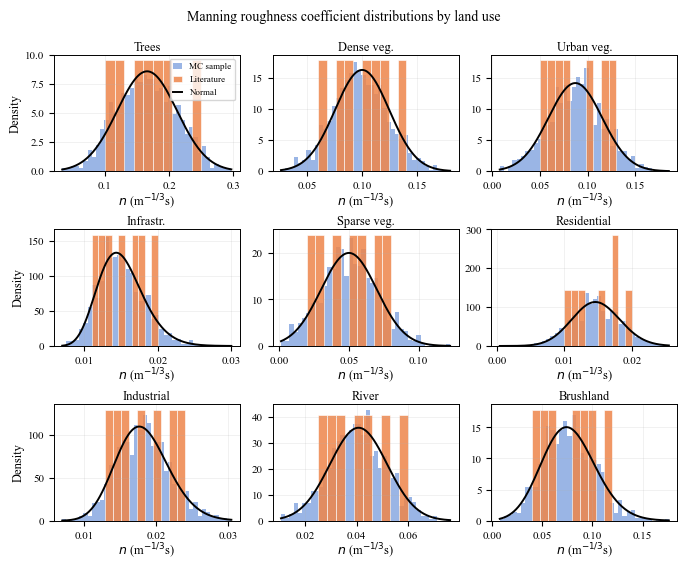

In [4]:
if _ext_ok:
    from scipy import stats as sc_stats
    
    CANDIDATES = ["norm", "lognorm", "gamma"]
    DIST_DISPLAY = {"norm": "Normal", "lognorm": "Log-normal", "gamma": "Gamma"}
    
    def best_dist(values):
        """Return (name, params) of the best-fitting distribution (KS test)."""
        best_name, best_p, best_par = None, -1, None
        for d in CANDIDATES:
            par = getattr(sc_stats, d).fit(values)
            _, p = sc_stats.kstest(values, d, args=par)
            if p > best_p:
                best_name, best_p, best_par = d, p, par
        return best_name, best_par
    
    fig, axes = plt.subplots(3, 3, figsize=(6.8, 5.5))
    axes = axes.flatten()
    
    for idx, (col, lbl) in enumerate(zip(LAND_USES, LABELS_SHORT)):
        row  = dist_df[dist_df["Descripción"] == col].iloc[0]
        vals = np.array([float(v) for v in str(row["N"]).split(",")])
        mc   = comb[col].values
        name, par = best_dist(vals)
        dist_obj  = getattr(sc_stats, name)
    
        ax = axes[idx]
        ax.hist(mc,   bins=40, density=True, alpha=0.55, color="#4878d0",
                label="MC sample", linewidth=0)
        ax.hist(vals, density=True, alpha=0.85, color="#ee854a",
                label="Literature", linewidth=0.5, edgecolor="white")
        x   = np.linspace(mc.min(), mc.max(), 300)
        pdf = dist_obj.pdf(x, *par[:-2], loc=par[-2], scale=par[-1])
        ax.plot(x, pdf, "k-", lw=1.4, label=DIST_DISPLAY.get(name, name))
        ax.set_title(lbl, pad=3)
        ax.set_xlabel(r"$n$ (m$^{-1/3}$s)", labelpad=1)
        if idx % 3 == 0:
            ax.set_ylabel("Density", labelpad=2)
        if idx == 0:
            ax.legend(fontsize=6.5, loc="upper right", handlelength=1)
    
    plt.suptitle("Manning roughness coefficient distributions by land use", y=1.01, fontsize=10)
    plt.tight_layout(pad=0.5)
    for ext in ["pdf", "png"]:
        plt.savefig(FIG_DIR / f"fig01_manning_distributions.{ext}", bbox_inches="tight")
    plt.show()
    print("Fig. 1 saved.")
    
else:
    print('Fig. 1 skipped — external drive not available.')

## Fig. 2 — Monte Carlo ensemble boxplots

Fig. 2 saved.


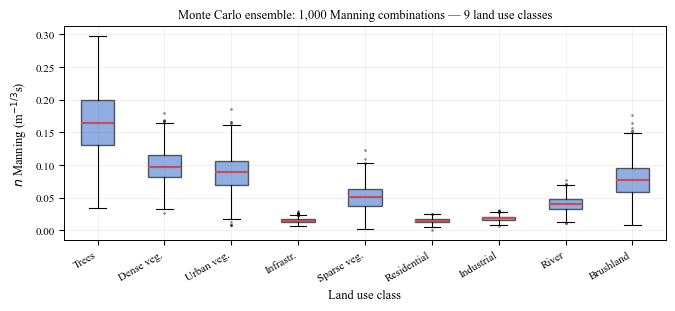

In [5]:
if _ext_ok:
    fig, ax = plt.subplots(figsize=(6.8, 3.2))
    bp = ax.boxplot(
        [comb[c].values for c in LAND_USES],
        tick_labels=LABELS_SHORT,
        patch_artist=True,
        medianprops={"color": "#c44e52", "lw": 1.5},
        whiskerprops={"lw": 0.8},
        capprops={"lw": 0.8},
        flierprops={"marker": ".", "ms": 2, "alpha": 0.4},
    )
    for patch in bp["boxes"]:
        patch.set_facecolor("#4878d0")
        patch.set_alpha(0.6)
    
    ax.set_ylabel(r"$n$ Manning (m$^{-1/3}$s)")
    ax.set_xlabel("Land use class")
    plt.xticks(rotation=30, ha="right")
    ax.set_title(
        "Monte Carlo ensemble: 1,000 Manning combinations — 9 land use classes"
    )
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(FIG_DIR / f"fig02_mc_boxplots.{ext}", bbox_inches="tight")
    plt.show()
    print("Fig. 2 saved.")
    
else:
    print('Fig. 2 skipped — external drive not available.')

## Fig. 3 — Intra-model sensitivity: Manning vs outputs (coloured by regime)

HEC-RAS points are coloured by the GMM-classified regime
(blue = LOW regime, red = HIGH regime). The **two horizontal bands**
visible in the HEC-RAS panels are the direct manifestation of the
hydraulic bifurcation identified in the regime analysis:
most simulations converge to the HIGH regime (≈0.70 km²)
and a minority to the LOW regime (≈0.58 km²), regardless of the
Manning value. SFINCS shows no banding because its distribution is unimodal.

Fig. 3 saved.

Band separation in HEC-RAS area: 0.700 km² (high) vs 0.577 km² (low)  →  Δ=0.124 km²


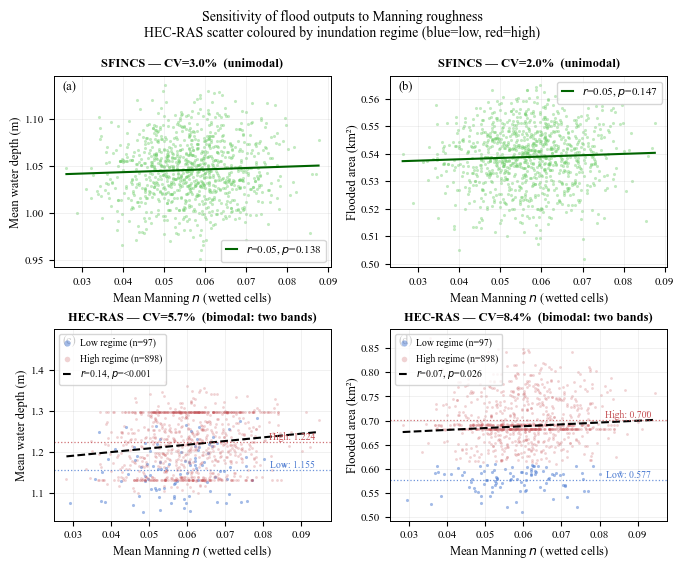

In [6]:
if _ext_ok:
    fig, axes = plt.subplots(2, 2, figsize=(6.8, 5.5))
    
    C_LOW  = "#4878d0"   # blue  — low regime / SFINCS
    C_HIGH = "#c44e52"   # red   — high regime
    C_SF   = "#6acc65"   # green — SFINCS
    
    # ── SFINCS rows ──────────────────────────────────────────────────────────────
    for col, ylabel, ax in [
        ("depth_mean",       "Mean water depth (m)", axes[0, 0]),
        ("flooded_area_km2", "Flooded area (km²)",   axes[0, 1]),
    ]:
        x = sf["manning_mean"]
        y = sf[col]
        sl, inter, r, p, _ = stats.linregress(x, y)
        xx = np.linspace(x.min(), x.max(), 100)
        ax.scatter(x, y, s=5, alpha=0.4, color=C_SF, linewidths=0)
        ax.plot(xx, sl * xx + inter, color="darkgreen", lw=1.5,
                label=fr"$r$={r:.2f}, $p$={'<0.001' if p<0.001 else f'{p:.3f}'}")
        ax.set_xlabel("Mean Manning $n$ (wetted cells)", labelpad=2)
        ax.set_ylabel(ylabel, labelpad=2)
        ax.set_title(f"SFINCS — CV={CV(y):.1f}%  (unimodal)", fontweight="bold")
        ax.legend(loc="best", handlelength=1)
    
    # ── HEC-RAS rows — coloured by regime ───────────────────────────────────────
    for col, ylabel, ax in [
        ("depth_mean",       "Mean water depth (m)", axes[1, 0]),
        ("flooded_area_km2", "Flooded area (km²)",   axes[1, 1]),
    ]:
        x_all = hr["manning_mean"]
        y_all = hr[col]
        sl, inter, r, p, _ = stats.linregress(x_all, y_all)
        xx = np.linspace(x_all.min(), x_all.max(), 100)
    
        # plot each regime separately
        ax.scatter(r0["manning_mean"], r0[col], s=5, alpha=0.5,
                   color=C_LOW,  linewidths=0, label=f"Low regime (n={len(r0)})")
        ax.scatter(r1["manning_mean"], r1[col], s=4, alpha=0.25,
                   color=C_HIGH, linewidths=0, label=f"High regime (n={len(r1)})")
        ax.plot(xx, sl * xx + inter, color="black", lw=1.5, ls="--",
                label=fr"$r$={r:.2f}, $p$={'<0.001' if p<0.001 else f'{p:.3f}'}")
    
        # annotate the two band levels
        for regime, color, label in [(r0, C_LOW, "Low"), (r1, C_HIGH, "High")]:
            level = regime[col].mean()
            ax.axhline(level, color=color, lw=0.9, ls=":", alpha=0.8)
            ax.annotate(f"{label}: {level:.3f}",
                        xy=(x_all.max() * 0.99, level),
                        xycoords="data", fontsize=7, color=color,
                        ha="right", va="bottom")
    
        ax.set_xlabel("Mean Manning $n$ (wetted cells)", labelpad=2)
        ax.set_ylabel(ylabel, labelpad=2)
        ax.set_title(f"HEC-RAS — CV={CV(y_all):.1f}%  (bimodal: two bands)",
                     fontweight="bold")
        ax.legend(loc="upper left", handlelength=1, markerscale=2, fontsize=7)
    
    for ax, lbl in zip(axes.flatten(), ["(a)","(b)","(c)","(d)"]):
        ax.annotate(lbl, xy=(0.03, 0.93), xycoords="axes fraction", fontsize=9)
    
    plt.suptitle(
        "Sensitivity of flood outputs to Manning roughness\n"
        "HEC-RAS scatter coloured by inundation regime (blue=low, red=high)",
        y=1.01, fontsize=10,
    )
    plt.tight_layout(pad=0.6)
    for ext in ["pdf", "png"]:
        plt.savefig(FIG_DIR / f"fig03_intramodel_sensitivity.{ext}", bbox_inches="tight")
    plt.show()
    print("Fig. 3 saved.")
    print(f"\nBand separation in HEC-RAS area: {r1['flooded_area_km2'].mean():.3f} km² (high) vs "
          f"{r0['flooded_area_km2'].mean():.3f} km² (low)  →  Δ={r1['flooded_area_km2'].mean()-r0['flooded_area_km2'].mean():.3f} km²")
    

## Fig. 4 — Inter-model comparison (1:1 scatter + KDE)

Fig. 4 saved.


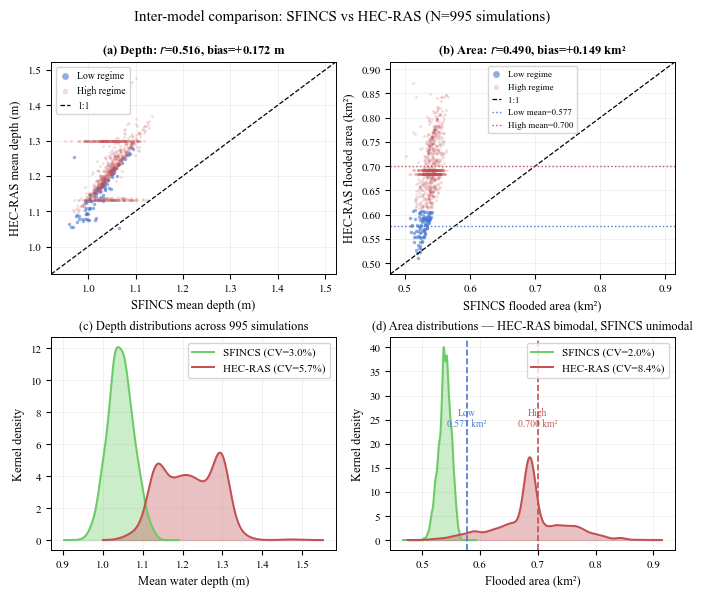

In [7]:
if _ext_ok:
    r_d, p_d = stats.pearsonr(comp["sfincs_depth_mean"], comp["hecras_depth_mean"])
    r_a, p_a = stats.pearsonr(comp["sfincs_area_km2"],   comp["hecras_area_km2"])
    bias_d    = (comp["hecras_depth_mean"] - comp["sfincs_depth_mean"]).mean()
    bias_a    = (comp["hecras_area_km2"]   - comp["sfincs_area_km2"]).mean()
    
    fig, axes = plt.subplots(2, 2, figsize=(6.8, 5.8))
    
    # (a) 1:1 depth — coloured by HR regime
    ax = axes[0, 0]
    ax.scatter(comp.loc[r0.index, "sfincs_depth_mean"],
               comp.loc[r0.index, "hecras_depth_mean"],
               s=6, alpha=0.6, color=C_LOW, linewidths=0, label="Low regime")
    ax.scatter(comp.loc[r1.index, "sfincs_depth_mean"],
               comp.loc[r1.index, "hecras_depth_mean"],
               s=4, alpha=0.2, color=C_HIGH, linewidths=0, label="High regime")
    lim = [comp[["sfincs_depth_mean","hecras_depth_mean"]].min().min()*0.97,
           comp[["sfincs_depth_mean","hecras_depth_mean"]].max().max()*1.03]
    ax.plot(lim, lim, "k--", lw=0.9, label="1:1")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("SFINCS mean depth (m)"); ax.set_ylabel("HEC-RAS mean depth (m)")
    ax.set_title(f"(a) Depth: $r$={r_d:.3f}, bias={bias_d:+.3f} m", fontweight="bold")
    ax.legend(handlelength=1, markerscale=2, fontsize=7)
    
    # (b) 1:1 area — coloured by HR regime; bands visible
    ax = axes[0, 1]
    ax.scatter(comp.loc[r0.index, "sfincs_area_km2"],
               comp.loc[r0.index, "hecras_area_km2"],
               s=6, alpha=0.6, color=C_LOW, linewidths=0, label="Low regime")
    ax.scatter(comp.loc[r1.index, "sfincs_area_km2"],
               comp.loc[r1.index, "hecras_area_km2"],
               s=4, alpha=0.2, color=C_HIGH, linewidths=0, label="High regime")
    lim2 = [comp[["sfincs_area_km2","hecras_area_km2"]].min().min()*0.95,
            comp[["sfincs_area_km2","hecras_area_km2"]].max().max()*1.05]
    ax.plot(lim2, lim2, "k--", lw=0.9, label="1:1")
    ax.axhline(r0["flooded_area_km2"].mean(), color=C_LOW,  lw=1, ls=":",
               label=f"Low mean={r0['flooded_area_km2'].mean():.3f}")
    ax.axhline(r1["flooded_area_km2"].mean(), color=C_HIGH, lw=1, ls=":",
               label=f"High mean={r1['flooded_area_km2'].mean():.3f}")
    ax.set_xlim(lim2); ax.set_ylim(lim2)
    ax.set_xlabel("SFINCS flooded area (km²)"); ax.set_ylabel("HEC-RAS flooded area (km²)")
    ax.set_title(f"(b) Area: $r$={r_a:.3f}, bias={bias_a:+.3f} km²", fontweight="bold")
    ax.legend(handlelength=1, fontsize=6.5, markerscale=2)
    
    # (c) KDE depth
    ax = axes[1, 0]
    for data, lbl, col_ in [(comp["sfincs_depth_mean"], "SFINCS", C_SF),
                             (comp["hecras_depth_mean"], "HEC-RAS", "#c44e52")]:
        kde = gaussian_kde(data, bw_method=0.3)
        xx  = np.linspace(data.min()*0.95, data.max()*1.05, 300)
        ax.fill_between(xx, kde(xx), alpha=0.35, color=col_)
        ax.plot(xx, kde(xx), color=col_, lw=1.4,
                label=f"{lbl} (CV={CV(data):.1f}%)")
    ax.set_xlabel("Mean water depth (m)"); ax.set_ylabel("Kernel density")
    ax.set_title("(c) Depth distributions across 995 simulations")
    ax.legend()
    
    # (d) KDE area — bimodal annotation
    ax = axes[1, 1]
    for data, lbl, col_ in [(comp["sfincs_area_km2"],"SFINCS", C_SF),
                             (comp["hecras_area_km2"],"HEC-RAS","#c44e52")]:
        kde = gaussian_kde(data, bw_method=0.15)
        xx  = np.linspace(data.min()*0.93, data.max()*1.05, 400)
        ax.fill_between(xx, kde(xx), alpha=0.35, color=col_)
        ax.plot(xx, kde(xx), color=col_, lw=1.4,
                label=f"{lbl} (CV={CV(data):.1f}%)")
    ymax = ax.get_ylim()[1]
    for level, col_, name in [
        (r0["flooded_area_km2"].mean(), C_LOW,  "Low"),
        (r1["flooded_area_km2"].mean(), C_HIGH, "High"),
    ]:
        ax.axvline(level, color=col_, lw=1.2, ls="--")
        ax.text(level, ymax * 0.55, f"{name}\n{level:.3f} km²",
                ha="center", va="bottom", fontsize=7, color=col_)
    ax.set_xlabel("Flooded area (km²)"); ax.set_ylabel("Kernel density")
    ax.set_title("(d) Area distributions — HEC-RAS bimodal, SFINCS unimodal")
    ax.legend()
    
    plt.suptitle("Inter-model comparison: SFINCS vs HEC-RAS (N=995 simulations)", y=1.01)
    plt.tight_layout(pad=0.6)
    for ext in ["pdf", "png"]:
        plt.savefig(FIG_DIR / f"fig04_intermodel_comparison.{ext}", bbox_inches="tight")
    plt.show()
    print("Fig. 4 saved.")
    

## Fig. 5 — Hydraulic bifurcation

In [8]:
if _ext_ok and _ras_ok:
    r0_idx = r0.index.tolist()
    r1_idx = r1.index.tolist()
    
    ref = rxr.open_rasterio(
        HECRAS_DIR / f"hamax_sim_{r0_idx[0]}.tif", masked=True
    ).squeeze("band", drop=True).rio.write_crs(CRS)
    
    dem = rxr.open_rasterio(str(DEM_PATH), masked=True).squeeze().rio.write_crs(CRS)
    dem_repr = dem.rio.reproject_match(ref)
    
    def build_freq(sims, n=60, seed=0):
        rng = np.random.default_rng(seed)
        sample = rng.choice(sims, min(n, len(sims)), replace=False)
        acc = xr.zeros_like(ref, dtype=float)
        for s in sorted(sample):
            f = HECRAS_DIR / f"hamax_sim_{s}.tif"
            if f.exists():
                da = rxr.open_rasterio(f, masked=True).squeeze("band", drop=True).rio.write_crs(CRS)
                acc += (da >= THR).fillna(0).astype(float)
        return acc / min(n, len(sims))
    
    print("Building frequency maps (this may take ~2 min)...")
    freq0 = build_freq(r0_idx, n=len(r0_idx))
    freq1 = build_freq(r1_idx, n=80)
    
    thresh_zone = (freq1 > 0.6) & (freq0 < 0.2)
    freq_diff   = freq1 - freq0
    
    # Topographic saddle ─────────────────────────────────────────────────────────
    always_bajo = xr.ones_like(ref, dtype=float)
    for s in r0_idx:
        f = HECRAS_DIR / f"hamax_sim_{s}.tif"
        if f.exists():
            da = rxr.open_rasterio(f, masked=True).squeeze("band", drop=True).rio.write_crs(CRS)
            always_bajo *= (da >= THR).fillna(0).astype(float)
    
    always_np = always_bajo.values > 0
    thresh_np = thresh_zone.values.astype(bool)
    dem_np    = dem_repr.values
    dil_t = ndimage.binary_dilation(thresh_np, iterations=5)
    dil_a = ndimage.binary_dilation(always_np, iterations=5)
    corridor = dil_t & dil_a & (~always_np) & (~thresh_np)
    c_rows, c_cols = np.where(corridor)
    elev_corr = dem_np[corridor]
    elev_corr = elev_corr[~np.isnan(elev_corr)]
    min_idx   = np.nanargmin(dem_np[corridor])
    SADDLE_X  = float(dem_repr.x.values[c_cols[min_idx]])
    SADDLE_Y  = float(dem_repr.y.values[c_rows[min_idx]])
    SADDLE_Z  = float(dem_np[c_rows[min_idx], c_cols[min_idx]])
    print(f"Saddle: X={SADDLE_X:.0f}  Y={SADDLE_Y:.0f}  z={SADDLE_Z:.2f} m")
    
    # Crop extent ────────────────────────────────────────────────────────────────
    ys, xs = np.where((freq1 > 0.05).values & (dem_repr.values < 85))
    xlim = [dem_repr.x.values[xs].min() - 200, dem_repr.x.values[xs].max() + 200]
    ylim = [dem_repr.y.values[ys].min() - 200, dem_repr.y.values[ys].max() + 200]
    y2d, x2d = np.meshgrid(freq0.y.values, freq0.x.values, indexing="ij")
    
else:
    print('Fig. 5 raster preparation skipped: external HEC-RAS rasters/DEM are not mounted.')


Fig. 5 raster preparation skipped: external HEC-RAS rasters/DEM are not mounted.


In [9]:
if _ext_ok and _ras_ok:
    import matplotlib.lines as mlines
    from matplotlib.colors import LightSource
    
    # ── Hillshade (reduced vert_exag for plan-view look) ─────────────────────
    dem_np_safe = np.where(np.isnan(dem_np), np.nanmean(dem_np[~np.isnan(dem_np)]), dem_np)
    ls = LightSource(azdeg=315, altdeg=45)
    hs_arr = ls.hillshade(dem_np_safe, vert_exag=2, dx=5, dy=5)
    hs_da = dem_repr.copy(data=hs_arr)
    
    def add_background(ax):
        hs_da.plot(ax=ax, cmap="Greys_r", vmin=0, vmax=1,
                   add_colorbar=False, alpha=0.30, zorder=0)
    
    def add_zone_contour(ax, lw=1.0):
        # Only cells within 500 m of the saddle (the actual secondary depression).
        # thresh_zone also flags cells along the main channel; the distance filter
        # removes those, leaving just the local topographic hollow.
        sr = int(np.argmin(np.abs(dem_repr.y.values - SADDLE_Y)))
        sc = int(np.argmin(np.abs(dem_repr.x.values - SADDLE_X)))
        rows, cols = np.ogrid[0:thresh_zone.shape[0], 0:thresh_zone.shape[1]]
        dist_cells = np.sqrt((rows - sr)**2 + (cols - sc)**2)
        local_zone = (thresh_zone.values > 0) & (dist_cells < 100)   # 100 cells × 5 m = 500 m
        # Close small gaps, smooth boundary, draw above frequency data
        closed = ndimage.binary_closing(local_zone, iterations=5).astype(float)
        smooth = ndimage.gaussian_filter(closed, sigma=3)
        ax.contour(x2d, y2d, smooth, levels=[0.5],
                   colors="black", linewidths=lw, linestyles="--", zorder=3)
    
    def map_panel(ax, freq, title, cmap, cbar_label):
        add_background(ax)
        freq.where(freq > 0.05).plot(
            ax=ax, cmap=cmap, alpha=0.85, vmin=0, vmax=1, zorder=2,
            cbar_kwargs={"label": cbar_label, "shrink": 0.72,
                         "pad": 0.02, "aspect": 20,
                         "ticks": [0, 0.25, 0.5, 0.75, 1]})
        add_zone_contour(ax)                 # zorder=3 — encima de la frecuencia
        ax.plot(SADDLE_X, SADDLE_Y, marker="^", color="#ee1111", ms=8, zorder=9,
                markeredgecolor="white", markeredgewidth=0.8)
        ax.set_aspect("equal", adjustable="datalim")
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_title(title, pad=3, fontsize=8)
        ax.set_xlabel("Easting (m)", labelpad=2, fontsize=7)
        ax.set_ylabel("Northing (m)", labelpad=2, fontsize=7)
        ax.tick_params(labelsize=6)
        saddle_h = mlines.Line2D([], [], marker="^", color="#ee1111", ms=7,
                                  ls="none", markeredgecolor="white",
                                  markeredgewidth=0.7,
                                  label=f"Saddle z=60.1 m a.s.l.")
        zone_h = mlines.Line2D([], [], color="black", ls="--", lw=1.2,
                                label="Secondary zone (~7.4 ha)")
        ax.legend(handles=[saddle_h, zone_h], fontsize=6.5, loc="lower right",
                  handlelength=1.6, borderpad=0.5, framealpha=0.85)
    
    fig = plt.figure(figsize=(7.2, 6.5))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.42,
                             height_ratios=[2.8, 2.8, 1.5])
    
    # (a) Low regime
    ax0 = fig.add_subplot(gs[0, 0])
    map_panel(ax0, freq0,
        f"(a) Low regime  $N$={len(r0_idx)},  $\\bar{{A}}$={r0['flooded_area_km2'].mean():.3f} km²",
        "Blues", "Inundation frequency")
    
    # (b) High regime
    ax1 = fig.add_subplot(gs[0, 1])
    map_panel(ax1, freq1,
        f"(b) High regime  $N$={len(r1_idx)},  $\\bar{{A}}$={r1['flooded_area_km2'].mean():.3f} km²",
        "Reds", "Inundation frequency")
    ax1.set_ylabel("")
    
    # (c) frequency difference
    ax2 = fig.add_subplot(gs[1, :])
    add_background(ax2)
    vmax_ = float(abs(freq_diff).quantile(0.995))
    freq_diff.where(abs(freq_diff) > 0.03).plot(
        ax=ax2, cmap="RdBu_r", vmin=-vmax_, vmax=vmax_, alpha=0.82, zorder=2,
        cbar_kwargs={"label": "Δ inundation frequency (High − Low)",
                     "shrink": 0.60, "pad": 0.015})
    add_zone_contour(ax2, lw=0.9)
    ax2.plot(SADDLE_X, SADDLE_Y, marker="^", color="#ee1111", ms=8, zorder=9,
            markeredgecolor="white", markeredgewidth=0.8)
    ax2.set_aspect("equal", adjustable="datalim")
    ax2.set_xlim(xlim); ax2.set_ylim(ylim)
    ax2.set_title(
        "(c) Frequency difference — red: cells exclusive to high regime (secondary floodplain)",
        pad=3, fontsize=8)
    ax2.set_xlabel("Easting (m)", labelpad=2, fontsize=7)
    ax2.set_ylabel("Northing (m)", labelpad=2, fontsize=7)
    ax2.tick_params(labelsize=6)
    
    # (d) area distributions
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.hist(sf["flooded_area_km2"], bins=30, color=C_SF,   alpha=0.65, label="SFINCS")
    ax3.hist(r0["flooded_area_km2"], bins=15, color=C_LOW,  alpha=0.85,
             label=f"HEC-RAS low (N={len(r0_idx)})")
    ax3.hist(r1["flooded_area_km2"], bins=30, color=C_HIGH, alpha=0.55,
             label=f"HEC-RAS high (N={len(r1_idx)})")
    ax3.set_xlabel("Flooded area (km²)", labelpad=2, fontsize=7)
    ax3.set_ylabel("Count", labelpad=2, fontsize=7)
    ax3.set_title("(d) Area distributions by model and regime", pad=3, fontsize=8)
    ax3.legend(handlelength=1, fontsize=6.5, loc="upper left")
    ax3.tick_params(labelsize=6)
    
    # (e) SFINCS area vs HEC-RAS regime
    ax4 = fig.add_subplot(gs[2, 1])
    ax4.scatter(sf.loc[r1_idx, "flooded_area_km2"], r1["flooded_area_km2"],
                s=4, alpha=0.20, color=C_HIGH, linewidths=0,
                label=f"High (N={len(r1_idx)})")
    ax4.scatter(sf.loc[r0_idx, "flooded_area_km2"], r0["flooded_area_km2"],
                s=10, alpha=0.70, color=C_LOW,  linewidths=0,
                label=f"Low (N={len(r0_idx)})")
    rho_v, _ = stats.spearmanr(sf["flooded_area_km2"], hr["regime"])
    ax4.set_xlabel("SFINCS flooded area (km²)", labelpad=2, fontsize=7)
    ax4.set_ylabel("HEC-RAS flooded area (km²)", labelpad=2, fontsize=7)
    ax4.set_title(fr"(e) SFINCS area as regime predictor ($\rho$={rho_v:.2f})",
                  pad=3, fontsize=8)
    ax4.legend(handlelength=1, markerscale=2, fontsize=6.5)
    ax4.tick_params(labelsize=6)
    
    plt.suptitle(
        f"Hydraulic bifurcation — Besaya River at Corrales de Buelna\n"
        f"Topographic saddle: z=60.1 m a.s.l.  "
        fr"(X={SADDLE_X:.0f}, Y={SADDLE_Y:.0f}, EPSG:25830)",
        y=1.01, fontsize=9, fontweight="bold",
    )
    for ext in ["pdf", "png"]:
        plt.savefig(FIG_DIR / f"fig05_hydraulic_bifurcation.{ext}",
                    bbox_inches="tight", dpi=300)
    plt.show()
    print("Fig. 5 saved.")
    
else:
    print('Fig. 5 plot skipped: external HEC-RAS rasters/DEM are not mounted.')


Fig. 5 plot skipped: external HEC-RAS rasters/DEM are not mounted.


## Fig. 6 — Coefficient of variation by model

Fig. 6 saved.


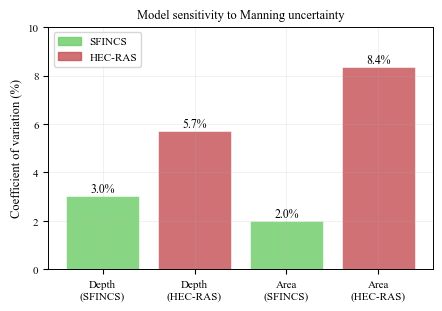

In [10]:
if _ext_ok:
    fig, ax = plt.subplots(figsize=(4.5, 3.2))
    groups   = ["Depth\n(SFINCS)", "Depth\n(HEC-RAS)", "Area\n(SFINCS)", "Area\n(HEC-RAS)"]
    cvs      = [CV(sf["depth_mean"]), CV(hr["depth_mean"]),
                CV(sf["flooded_area_km2"]), CV(hr["flooded_area_km2"])]
    colors_b = [C_SF, "#c44e52", C_SF, "#c44e52"]
    
    bars = ax.bar(groups, cvs, color=colors_b, alpha=0.8,
                  edgecolor="white", linewidth=0.5)
    for bar, v in zip(bars, cvs):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.05,
                f"{v:.1f}%", ha="center", va="bottom", fontsize=8.5)
    
    ax.set_ylabel("Coefficient of variation (%)")
    ax.set_title("Model sensitivity to Manning uncertainty")
    sf_patch = mpatches.Patch(color=C_SF,     alpha=0.8, label="SFINCS")
    hr_patch = mpatches.Patch(color="#c44e52",alpha=0.8, label="HEC-RAS")
    ax.legend(handles=[sf_patch, hr_patch])
    ax.set_ylim(0, max(cvs) * 1.2)
    plt.tight_layout()
    for ext in ["pdf", "png"]:
        plt.savefig(FIG_DIR / f"fig06_cv_comparison.{ext}", bbox_inches="tight")
    plt.show()
    print("Fig. 6 saved.")
    

## Summary of generated figures

| File | Figure in article |
|---------|----------------------|
| `fig01_manning_distributions.*` | Fig. 1 — Distributions by land-use class |
| `fig02_mc_boxplots.*`           | Fig. 2 — MC ensemble boxplots |
| `fig03_intramodel_sensitivity.*`| Fig. 3 — Manning vs outputs scatter (**with regime colouring**) |
| `fig04_intermodel_comparison.*` | Fig. 4 — Inter-model comparison |
| `fig05_hydraulic_bifurcation.*` | Fig. 5 — Hydraulic bifurcation |
| `fig06_cv_comparison.*`         | Fig. 6 — CV by model |

All figures are saved in PDF (for LaTeX) and PNG (for review).

## Fig 7 — Alternative metrics (volume & median depth)
These avoid the discrete wet-cell averaging artifact visible in the mean depth scatter.


Volume CV  — SFINCS: 4.8%   HEC-RAS: 11.7%
Median CV  — SFINCS: 5.8%   HEC-RAS: 4.6%


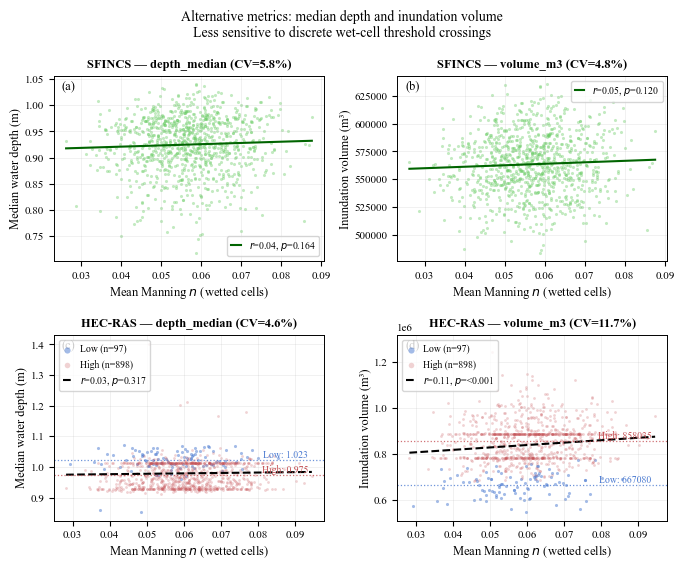

In [11]:
if _ext_ok:
    
    # ── Fig 7: Alternative metrics — inundation volume and median depth ──────────
    # These metrics are less sensitive to discrete wet/dry threshold crossings
    # because marginal cells (h ≈ 0.05 m) contribute negligible volume.
    
    from scipy import stats as sc_stats
    
    # Compute inundation volume (m³) from existing CSV columns
    sf["volume_m3"] = sf["depth_mean"] * sf["flooded_area_km2"] * 1e6
    hr["volume_m3"] = hr["depth_mean"] * hr["flooded_area_km2"] * 1e6
    # Re-slice regime subsets so they include the new volume column
    r0 = hr[hr["regime"] == 0]
    r1 = hr[hr["regime"] == 1]
    
    fig, axes = plt.subplots(2, 2, figsize=(6.8, 5.5))
    
    C_LOW  = "#4878d0"
    C_HIGH = "#c44e52"
    C_SF   = "#6acc65"
    
    METRICS = [
        ("depth_median",  r"Median water depth (m)",    "depth_median",  "depth_median"),
        ("volume_m3",     r"Inundation volume (m³)",    "volume_m3",     "volume_m3"),
    ]
    
    for col_idx, (metric, ylabel, sf_col, hr_col) in enumerate(METRICS):
        # ── SFINCS ──────────────────────────────────────────────────────────────
        ax = axes[0, col_idx]
        x = sf["manning_mean"]; y = sf[sf_col]
        sl, inter, r, p, _ = sc_stats.linregress(x, y)
        xx = np.linspace(x.min(), x.max(), 100)
        ax.scatter(x, y, s=5, alpha=0.4, color=C_SF, linewidths=0)
        ax.plot(xx, sl*xx+inter, color="darkgreen", lw=1.5,
                label=fr"$r$={r:.2f}, $p$={'<0.001' if p<0.001 else f'{p:.3f}'}")
        ax.set_xlabel("Mean Manning $n$ (wetted cells)", labelpad=2)
        ax.set_ylabel(ylabel, labelpad=2)
        cv = y.std()/y.mean()*100
        ax.set_title(f"SFINCS — {metric} (CV={cv:.1f}%)", fontweight="bold")
        ax.legend(loc="best", handlelength=1, fontsize=7)
    
        # ── HEC-RAS ─────────────────────────────────────────────────────────────
        ax = axes[1, col_idx]
        x_all = hr["manning_mean"]; y_all = hr[hr_col]
        sl, inter, r, p, _ = sc_stats.linregress(x_all, y_all)
        xx = np.linspace(x_all.min(), x_all.max(), 100)
    
        ax.scatter(r0[hr_col], r0["manning_mean"].values,  # intentional flip — see below
                   s=5, alpha=0.5, color=C_LOW,  linewidths=0)  # reset below
        ax.cla()
        ax.scatter(r0["manning_mean"], r0[hr_col], s=5, alpha=0.5,
                   color=C_LOW,  linewidths=0, label=f"Low (n={len(r0)})")
        ax.scatter(r1["manning_mean"], r1[hr_col], s=4, alpha=0.25,
                   color=C_HIGH, linewidths=0, label=f"High (n={len(r1)})")
        ax.plot(xx, sl*xx+inter, color="black", lw=1.5, ls="--",
                label=fr"$r$={r:.2f}, $p$={'<0.001' if p<0.001 else f'{p:.3f}'}")
        # Band means
        for regime, color, label in [(r0, C_LOW, "Low"), (r1, C_HIGH, "High")]:
            lv = regime[hr_col].mean()
            ax.axhline(lv, color=color, lw=0.9, ls=":", alpha=0.8)
            ax.annotate(f"{label}: {lv:.0f}" if metric=="volume_m3" else f"{label}: {lv:.3f}",
                        xy=(x_all.max()*0.99, lv), xycoords="data",
                        fontsize=7, color=color, ha="right", va="bottom")
        ax.set_xlabel("Mean Manning $n$ (wetted cells)", labelpad=2)
        ax.set_ylabel(ylabel, labelpad=2)
        cv = y_all.std()/y_all.mean()*100
        ax.set_title(f"HEC-RAS — {metric} (CV={cv:.1f}%)", fontweight="bold")
        ax.legend(loc="upper left", handlelength=1, markerscale=2, fontsize=7)
    
    for ax, lbl in zip(axes.flatten(), ["(a)","(b)","(c)","(d)"]):
        ax.annotate(lbl, xy=(0.03, 0.93), xycoords="axes fraction", fontsize=9)
    
    plt.suptitle(
        "Alternative metrics: median depth and inundation volume\n"
        "Less sensitive to discrete wet-cell threshold crossings",
        y=1.01, fontsize=10,
    )
    plt.tight_layout(pad=0.6)
    for ext in ["pdf", "png"]:
        plt.savefig(FIG_DIR / f"fig07_alternative_metrics.{ext}", bbox_inches="tight")
    plt.show()
    
    cv_vol_hr = hr["volume_m3"].std()/hr["volume_m3"].mean()*100
    cv_vol_sf = sf["volume_m3"].std()/sf["volume_m3"].mean()*100
    cv_med_hr = hr["depth_median"].std()/hr["depth_median"].mean()*100
    cv_med_sf = sf["depth_median"].std()/sf["depth_median"].mean()*100
    print(f"Volume CV  — SFINCS: {cv_vol_sf:.1f}%   HEC-RAS: {cv_vol_hr:.1f}%")
    print(f"Median CV  — SFINCS: {cv_med_sf:.1f}%   HEC-RAS: {cv_med_hr:.1f}%")
    